## GTM294 Example 2.4


We are interested in solving the transport equation
$$
u_t + xu_x = 0 \quad x \in \mathbb{R} \\
u(0,x)=u_0(x)
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm

In [2]:
def shift_numpy_array(array : np.ndarray, step : int):
    if(step > 0): #shift right
        array = np.pad(array[0 : len(array)-step], pad_width=(step, 0), constant_values=0)
    elif(step < 0): #shift left
        step = -step
        array = np.pad(array[step : len(array)], pad_width=(0, step), constant_values=0)
    return array 

def pad(array):
    return np.concatenate([[array[0]], array, [array[-1]]]) 

In [3]:
def solve_transport(u0, a, grid, dt, T):
    """Solve transport equation 
        u_t + a(u,x,t)u_x = 0

    Args:
        u0 (NDArray): initial condition
        a (callable): a(u, x,t) 
        grid (NDArray): the grid given by, for instance, np.linspace 
        dt (float): time step
        T (float): Total phyisical time 

    Returns:
        NDArray: 2D array that has the entire history
    """
    dx = grid[1] - grid[0]
    print(" ==== Solving 1D transport equation using semi-discrete FD ==== ")
    print(f" N = {len(u0)}| dx = {dx} | dt = {dt} | T (total simulation time) = {T} | total_steps = {int(T/dt)}")
    us = np.empty(shape=(int(T / dt), len(u0)))
    us[0] = u0
    for t in range(int(T/dt)-1):
        u_ip1 = shift_numpy_array(us[t], -1)
        u_im1 = shift_numpy_array(us[t], 1)
        u_m = u_ip1 - us[t]
        u_p = us[t] - u_im1
        
        a_m = np.where(a(us[t],grid,t)<0.0, a(us[t],grid,t), 0.0) 
        a_p = np.where(a(us[t],grid,t)>0.0, a(us[t],grid,t), 0.0) 
        du = (dt/dx) * (a_p * u_p + a_m * u_m)
        us[t+1] = us[t] - du 
    return us 

In [4]:
def animate_solution(us, grid, path, coarsen_factor=10):
    print(f" ==== animating solution to pde ====")
    fig, ax = plt.subplots()
    frames = int(us.shape[0]/coarsen_factor)
    print(f" total frames = {frames} ")
    pbar = tqdm(total=frames)
    line, = ax.plot(grid, us[0])
    ax.set_ylim(0.0,1.0)
    def update(frame):
        t = frame * coarsen_factor
        pbar.update()
        line.set_ydata(us[t])
        return [line]
    ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)
    pbar.close()
    ani.save(path)

In [5]:
from matplotlib import cm
def plot_u(us, dt, T, space_grid):
    grid_x, grid_t = np.meshgrid(space_grid, np.linspace(0, T, int(T/dt)), indexing='xy')
    print(grid_t.shape)
    print(grid_x.shape)
    print(us.shape)
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.view_init(elev=20, azim=-110) 
    ax.set_zlim(0.0,1.0)
    ax.plot_surface(X=grid_x, Y=grid_t, Z=us,cmap=cm.coolwarm, linewidth=0)

## Define Initial Condition and $a(x,t)$

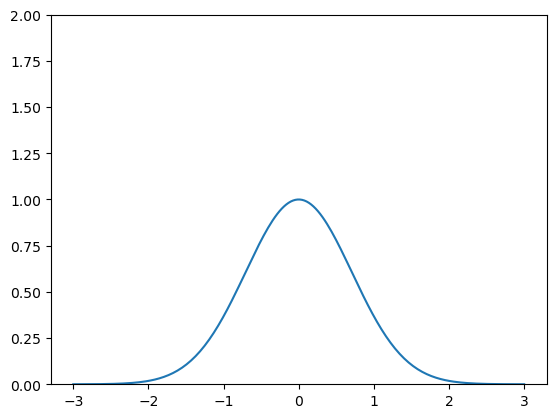

In [55]:
x = np.linspace(-3.0, 3.0, 200)
# u0 = np.where(x<1, x, np.exp(-x**2))
u0 = np.exp(-(x)**2)
fig, ax = plt.subplots()
ax.set_ylim(0.0,2.0)
ax.plot(x, u0)

# define a(x,t)
def a(u, x,t):
    return 1.0

## Solve equation

In [56]:
us = solve_transport(u0=u0, a=a, grid=x, dt=0.001, T=2.0)

 ==== Solving 1D transport equation using semi-discrete FD ==== 
 N = 200| dx = 0.03015075376884413 | dt = 0.001 | T (total simulation time) = 2.0 | total_steps = 2000


## Animate Solution

 ==== animating solution to pde ====
 total frames = 40 


  5%|▌         | 2/40 [00:00<00:00, 65.12it/s]


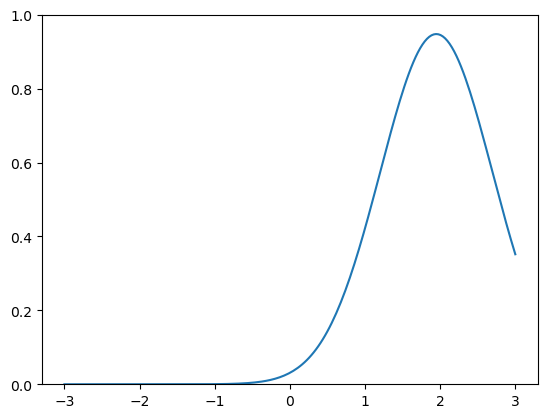

In [65]:
path="output/solution.mp4"
animate_solution(us=us, grid=x, coarsen_factor=50, path=path)

## Visualize $u(t,x)$

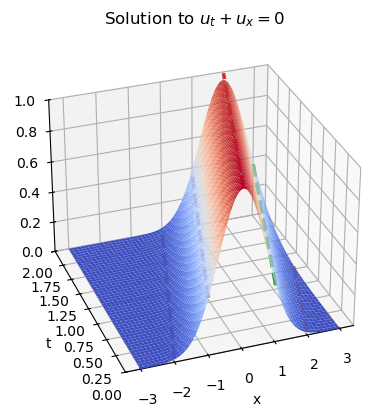

In [64]:
t=np.linspace(0, 2.0, int(2.0/0.001))
grid_x, grid_t = np.meshgrid(x, t, indexing='xy')
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
cs = np.arange(-3.0, 3.0, 1.0)
# characteristic curve 
for c in cs:
    t_masked = np.ma.masked_outside(1.0 * x + c, v1=0.0, v2=2.0) #t(x)
    constant = us[0, int((c+3.0) / 6.0 * 200)]
    ax.plot(x, t_masked, constant, linewidth=2.5, linestyle='dashed')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(r"Solution to $u_t+u_x=0$")
ax.view_init(elev=30, azim=-110) 
ax.set_ylim(bottom=0.0, top=2.0) #y is t
ax.set_zlim(0.0,1.0)
ax.plot_surface(X=grid_x, Y=grid_t, Z=us,cmap=cm.coolwarm, linewidth=0)
plt.savefig("output/ex1")